# Taxi Demand Prediction & Urban Mobility Analytics

## Project Objective

Analyze NYC Yellow Taxi trip data to understand how taxi demand varies by time and location, identify peak-demand patterns, and build a machine learning model to predict taxi demand.

### Tools & Technologies
- Excel – initial dataset inspection
- Python – data cleaning, exploratory data analysis and feature engineering
- Machine Learning – taxi demand prediction
- Power BI – interactive dashboard and data storytelling
- Statistics / Time Series – trends, seasonality and peak-demand analysis

### Dataset
NYC Yellow Taxi Trip Record Data – January 2025

### Key Business Questions
1. When is taxi demand highest?
2. Which pickup zones experience the highest demand?
3. How does demand vary by hour and day of the week?
4. What are the peak-demand periods?
5. Can historical demand patterns be used to predict future taxi demand?
6. What insights can help improve taxi availability and urban mobility planning?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [3]:
import numpy as np

print("NumPy version:", np.__version__)
print("NumPy location:", np.__file__)

NumPy version: 1.26.4
NumPy location: C:\Users\Sai Pratheek\anaconda3\Lib\site-packages\numpy\__init__.py


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

print("Pandas version:", pd.__version__)
print("Matplotlib imported successfully!")

Pandas version: 2.2.2
Matplotlib imported successfully!


In [7]:
import pandas as pd

file_path = r"C:\Users\Sai Pratheek\OneDrive\Desktop\Taxi Demand Prediction\01_Raw_Data\yellow_tripdata_2025-01.parquet"

df = pd.read_parquet(file_path)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Dataset loaded successfully!
Rows: 3475226
Columns: 20


In [9]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

In [13]:
df.isnull().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
store_and_fwd_flag       540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     540149
Airport_fee              540149
cbd_congestion_fee            0
dtype: int64

In [15]:
print("Pickup date range:")
print(df["tpep_pickup_datetime"].min())
print(df["tpep_pickup_datetime"].max())

print("\nDrop-off date range:")
print(df["tpep_dropoff_datetime"].min())
print(df["tpep_dropoff_datetime"].max())

Pickup date range:
2024-12-31 20:47:55
2025-02-01 00:00:44

Drop-off date range:
2024-12-18 07:52:40
2025-02-01 23:44:11


In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [19]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,3475226.0,1.785428,1.0,2.0,2.0,2.0,7.0,0.426328
tpep_pickup_datetime,3475226,2025-01-17 11:02:55.910964,2024-12-31 20:47:55,2025-01-10 07:59:01,2025-01-17 15:41:33,2025-01-24 19:34:06,2025-02-01 00:00:44,NaN
tpep_dropoff_datetime,3475226,2025-01-17 11:17:56.997901,2024-12-18 07:52:40,2025-01-10 08:15:29.500000,2025-01-17 15:59:34,2025-01-24 19:48:31,2025-02-01 23:44:11,NaN
passenger_count,2935077.0,1.297859,0.0,1.0,1.0,1.0,9.0,0.75075
trip_distance,3475226.0,5.855126,0.0,0.98,1.67,3.1,276423.57,564.6016
RatecodeID,2935077.0,2.482535,1.0,1.0,1.0,1.0,99.0,11.632772
PULocationID,3475226.0,165.191576,1.0,132.0,162.0,234.0,265.0,64.529483
DOLocationID,3475226.0,164.125177,1.0,113.0,162.0,234.0,265.0,69.401686
payment_type,3475226.0,1.036623,0.0,1.0,1.0,1.0,5.0,0.701333
fare_amount,3475226.0,17.081803,-900.0,8.6,12.11,19.5,863372.12,463.472918


In [21]:
# Check records outside January 2025 based on pickup time

start_date = pd.Timestamp("2025-01-01")
end_date = pd.Timestamp("2025-02-01")

outside_january = (
    (df["tpep_pickup_datetime"] < start_date) |
    (df["tpep_pickup_datetime"] >= end_date)
)

print("Records outside January 2025:", outside_january.sum())
print("Percentage:", round(outside_january.mean() * 100, 2), "%")


# Calculate trip duration in minutes
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print("\nTrip duration statistics:")
print(df["trip_duration_minutes"].describe())

Records outside January 2025: 22
Percentage: 0.0 %

Trip duration statistics:
count    3.475226e+06
mean     1.501812e+01
std      3.871358e+01
min     -5.147232e+04
25%      7.283333e+00
50%      1.170000e+01
75%      1.833333e+01
max      5.626317e+03
Name: trip_duration_minutes, dtype: float64


In [23]:
duration_checks = {
    "Negative duration": (df["trip_duration_minutes"] < 0).sum(),
    "Zero duration": (df["trip_duration_minutes"] == 0).sum(),
    "Over 1 hour": (df["trip_duration_minutes"] > 60).sum(),
    "Over 2 hours": (df["trip_duration_minutes"] > 120).sum(),
    "Over 3 hours": (df["trip_duration_minutes"] > 180).sum(),
    "Over 24 hours": (df["trip_duration_minutes"] > 1440).sum()
}

for condition, count in duration_checks.items():
    print(f"{condition}: {count:,}")

Negative duration: 124
Zero duration: 1,927
Over 1 hour: 31,867
Over 2 hours: 2,014
Over 3 hours: 1,377
Over 24 hours: 20


In [25]:
duration_percentiles = df["trip_duration_minutes"].quantile(
    [0.90, 0.95, 0.99, 0.995, 0.999]
)

print(duration_percentiles)

0.900    27.550000
0.950    36.200000
0.990    58.916667
0.995    67.900000
0.999    98.262917
Name: trip_duration_minutes, dtype: float64


In [27]:
print("Zero distance:", (df["trip_distance"] == 0).sum())
print("Negative distance:", (df["trip_distance"] < 0).sum())
print("Over 50 miles:", (df["trip_distance"] > 50).sum())
print("Over 100 miles:", (df["trip_distance"] > 100).sum())
print("Over 500 miles:", (df["trip_distance"] > 500).sum())

Zero distance: 90893
Negative distance: 0
Over 50 miles: 533
Over 100 miles: 162
Over 500 miles: 118


In [29]:
zero_distance = df[df["trip_distance"] == 0]

print("Zero-distance trips:", len(zero_distance))

print("\nDuration of zero-distance trips:")
print(zero_distance["trip_duration_minutes"].describe())

print("\nSample zero-distance trips:")
display(
    zero_distance[
        [
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "trip_duration_minutes",
            "passenger_count",
            "PULocationID",
            "DOLocationID",
            "fare_amount",
            "total_amount"
        ]
    ].head(10)
)

Zero-distance trips: 90893

Duration of zero-distance trips:
count    90893.000000
mean        11.676019
std         27.820032
min          0.000000
25%          0.500000
50%         10.166667
75%         17.533333
max       4184.000000
Name: trip_duration_minutes, dtype: float64

Sample zero-distance trips:


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,passenger_count,PULocationID,DOLocationID,fare_amount,total_amount
92,2025-01-01 00:49:48,2025-01-01 00:49:48,0.000000,1.0,87,264,20.06,20.06
204,2025-01-01 00:37:43,2025-01-01 00:37:53,0.166667,1.0,148,148,12.00,17.50
358,2025-01-01 00:57:08,2025-01-01 00:57:16,0.133333,3.0,141,141,30.00,33.50
505,2025-01-01 00:27:40,2025-01-01 00:59:30,31.833333,1.0,168,76,50.50,58.94
619,2025-01-01 00:56:49,2025-01-01 00:56:54,0.083333,4.0,164,164,20.00,30.55
706,2025-01-01 00:42:42,2025-01-01 00:42:44,0.033333,0.0,261,261,3.00,10.35
1073,2025-01-01 00:43:22,2025-01-01 00:46:18,2.933333,1.0,48,48,5.00,9.00
1345,2025-01-01 00:24:26,2025-01-01 00:24:34,0.133333,4.0,60,60,20.00,25.20
1354,2025-01-01 00:14:57,2025-01-01 00:17:44,2.783333,1.0,79,79,3.00,8.00
1496,2025-01-01 00:49:10,2025-01-01 00:49:14,0.066667,4.0,143,143,85.00,115.05


In [31]:
extreme_distance = df[df["trip_distance"] > 500]

print("Trips over 500 miles:", len(extreme_distance))

display(
    extreme_distance[
        [
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "trip_duration_minutes",
            "trip_distance",
            "passenger_count",
            "PULocationID",
            "DOLocationID",
            "fare_amount",
            "total_amount"
        ]
    ].sort_values("trip_distance", ascending=False).head(20)
)

Trips over 500 miles: 118


,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,passenger_count,PULocationID,DOLocationID,fare_amount,total_amount
3275762,2025-01-22 21:04:00,2025-01-22 21:13:00,9.0,276423.57,NaN,161,170,-4.75,5.00
3188501,2025-01-19 14:51:00,2025-01-19 14:58:00,7.0,276099.95,NaN,224,233,9.13,13.88
3240337,2025-01-21 09:19:00,2025-01-21 09:45:00,26.0,222167.49,NaN,52,144,31.19,35.94
3112173,2025-01-16 10:47:00,2025-01-16 11:11:00,24.0,206137.99,NaN,263,48,24.89,29.64
3374854,2025-01-26 17:46:00,2025-01-26 17:59:00,13.0,202771.63,NaN,50,186,10.10,14.85
3081597,2025-01-14 19:18:00,2025-01-14 19:36:00,18.0,189687.43,NaN,246,164,12.70,17.45
3069039,2025-01-13 21:11:00,2025-01-13 21:17:00,6.0,181139.99,NaN,100,90,6.33,11.08
3312563,2025-01-24 08:33:00,2025-01-24 08:44:00,11.0,168079.57,NaN,42,238,-4.00,4.49
3195037,2025-01-19 18:31:00,2025-01-19 18:58:00,27.0,167452.94,NaN,247,239,-4.00,5.45
3138510,2025-01-17 14:25:00,2025-01-17 14:40:00,15.0,164959.95,NaN,262,239,14.05,18.05


In [33]:
print("Missing passenger count:", df["passenger_count"].isna().sum())
print("Zero passenger count:", (df["passenger_count"] == 0).sum())

print("\nPassenger count distribution:")
print(df["passenger_count"].value_counts(dropna=False).sort_index())

Missing passenger count: 540149
Zero passenger count: 24656

Passenger count distribution:
passenger_count
0.0      24656
1.0    2322434
2.0     407761
3.0      91409
4.0      59009
5.0      17786
6.0      12004
7.0          4
8.0         11
9.0          3
NaN     540149
Name: count, dtype: int64


In [35]:
invalid_time_order = (
    df["tpep_dropoff_datetime"] <= df["tpep_pickup_datetime"]
)

print("Drop-off before or equal to pickup:", invalid_time_order.sum())

Drop-off before or equal to pickup: 2051


In [37]:
# Create a copy of the original dataset
clean_df = df.copy()

# Define valid January 2025 pickup period
start_date = pd.Timestamp("2025-01-01")
end_date = pd.Timestamp("2025-02-01")

# Apply data-quality rules
clean_df = clean_df[
    (clean_df["tpep_pickup_datetime"] >= start_date) &
    (clean_df["tpep_pickup_datetime"] < end_date) &
    (clean_df["tpep_dropoff_datetime"] > clean_df["tpep_pickup_datetime"]) &
    (clean_df["trip_duration_minutes"] <= 180) &
    (clean_df["trip_distance"] <= 100)
].copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))
print("Percentage removed:", round((len(df) - len(clean_df)) / len(df) * 100, 2), "%")

Original rows: 3475226
Cleaned rows: 3471621
Rows removed: 3605
Percentage removed: 0.1 %


In [39]:
print("Cleaned dataset shape:", clean_df.shape)

print("\nPickup date range:")
print(clean_df["tpep_pickup_datetime"].min())
print(clean_df["tpep_pickup_datetime"].max())

print("\nTrip duration range:")
print(clean_df["trip_duration_minutes"].min())
print(clean_df["trip_duration_minutes"].max())

print("\nTrip distance range:")
print(clean_df["trip_distance"].min())
print(clean_df["trip_distance"].max())

print("\nInvalid time-order records:")
print(
    (
        clean_df["tpep_dropoff_datetime"]
        <= clean_df["tpep_pickup_datetime"]
    ).sum()
)

print("\nDistances over 100 miles:")
print((clean_df["trip_distance"] > 100).sum())

print("\nDurations over 3 hours:")
print((clean_df["trip_duration_minutes"] > 180).sum())

Cleaned dataset shape: (3471621, 21)

Pickup date range:
2025-01-01 00:00:00
2025-01-31 23:59:59

Trip duration range:
0.016666666666666666
179.96666666666667

Trip distance range:
0.0
98.5

Invalid time-order records:
0

Distances over 100 miles:
0

Durations over 3 hours:
0


In [41]:
clean_file_path = r"C:\Users\Sai Pratheek\OneDrive\Desktop\Taxi Demand Prediction\02_Cleaned_Data\yellow_taxi_january_2025_cleaned.parquet"

clean_df.to_parquet(clean_file_path, index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [43]:
# Create time-based features

clean_df["pickup_date"] = clean_df["tpep_pickup_datetime"].dt.date

clean_df["pickup_hour"] = clean_df["tpep_pickup_datetime"].dt.hour

clean_df["day_of_week"] = clean_df["tpep_pickup_datetime"].dt.dayofweek

clean_df["day_name"] = clean_df["tpep_pickup_datetime"].dt.day_name()

clean_df["month"] = clean_df["tpep_pickup_datetime"].dt.month

clean_df["is_weekend"] = clean_df["day_of_week"] >= 5

print("Time-based features created successfully!")

Time-based features created successfully!


In [45]:
hourly_demand = (
    clean_df
    .groupby("pickup_hour")
    .size()
    .reset_index(name="trip_count")
)

hourly_demand

,pickup_hour,trip_count
0,0,93333
1,1,64437
2,2,43877
3,3,28470
4,4,20009
5,5,22521
6,6,49981
7,7,102476
8,8,141119
9,9,142701


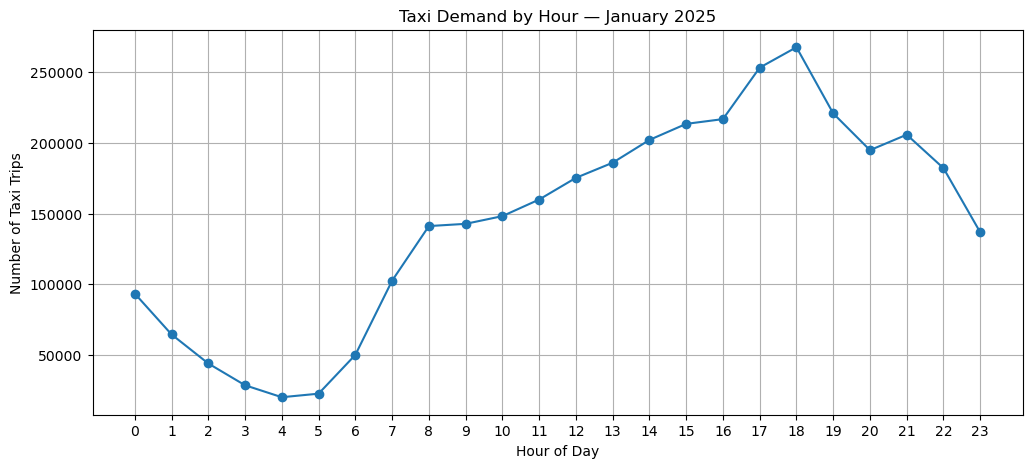

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_demand["pickup_hour"],
    hourly_demand["trip_count"],
    marker="o"
)

plt.title("Taxi Demand by Hour — January 2025")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Taxi Trips")
plt.xticks(range(24))
plt.grid(True)

plt.show()

In [51]:
clean_df["day_type"] = clean_df["tpep_pickup_datetime"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

clean_df[["tpep_pickup_datetime", "day_type"]].head()

,tpep_pickup_datetime,day_type
0,2025-01-01 00:18:38,Weekday
1,2025-01-01 00:32:40,Weekday
2,2025-01-01 00:44:04,Weekday
3,2025-01-01 00:14:27,Weekday
4,2025-01-01 00:21:34,Weekday


In [53]:
clean_df["day_type"].value_counts()

day_type
Weekday    2593391
Weekend     878230
Name: count, dtype: int64

In [55]:
day_demand = (
    clean_df
    .groupby(["day_type", "pickup_hour"])
    .size()
    .reset_index(name="trip_count")
)

day_demand

,day_type,pickup_hour,trip_count
0,Weekday,0,42977
1,Weekday,1,25077
2,Weekday,2,16475
3,Weekday,3,11609
4,Weekday,4,10853
5,Weekday,5,18242
6,Weekday,6,43147
7,Weekday,7,92343
8,Weekday,8,125299
9,Weekday,9,117777


In [57]:
# Number of unique calendar days in each day type
days_by_type = (
    clean_df.groupby("day_type")["tpep_pickup_datetime"]
    .apply(lambda x: x.dt.date.nunique())
)

days_by_type

day_type
Weekday    23
Weekend     8
Name: tpep_pickup_datetime, dtype: int64

In [59]:
# Calculate hourly trips
day_demand = (
    clean_df
    .groupby(["day_type", "pickup_hour"])
    .size()
    .reset_index(name="trip_count")
)

# Add number of days for each day type
day_demand["number_of_days"] = day_demand["day_type"].map(days_by_type)

# Average trips per day for each hour
day_demand["avg_trips_per_day"] = (
    day_demand["trip_count"] / day_demand["number_of_days"]
)

day_demand.head(10)

,day_type,pickup_hour,trip_count,number_of_days,avg_trips_per_day
0,Weekday,0,42977,23,1868.565217
1,Weekday,1,25077,23,1090.304348
2,Weekday,2,16475,23,716.304348
3,Weekday,3,11609,23,504.739130
4,Weekday,4,10853,23,471.869565
5,Weekday,5,18242,23,793.130435
6,Weekday,6,43147,23,1875.956522
7,Weekday,7,92343,23,4014.913043
8,Weekday,8,125299,23,5447.782609
9,Weekday,9,117777,23,5120.739130


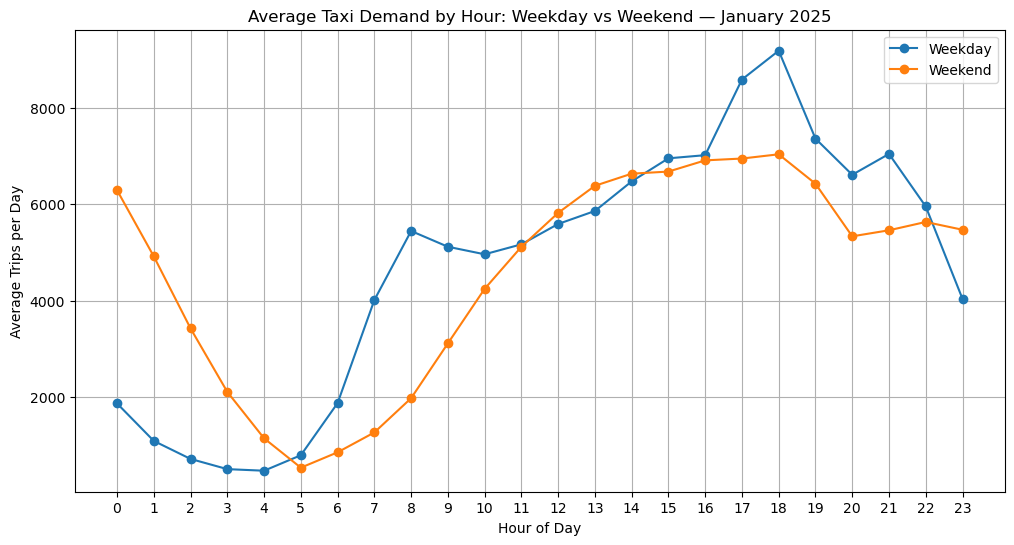

In [61]:
plt.figure(figsize=(12, 6))

for day_type in ["Weekday", "Weekend"]:
    subset = day_demand[day_demand["day_type"] == day_type]

    plt.plot(
        subset["pickup_hour"],
        subset["avg_trips_per_day"],
        marker="o",
        label=day_type
    )

plt.title("Average Taxi Demand by Hour: Weekday vs Weekend — January 2025")
plt.xlabel("Hour of Day")
plt.ylabel("Average Trips per Day")
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()

In [63]:
location_demand = (
    clean_df
    .groupby("PULocationID")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

location_demand.head(15)

,PULocationID,trip_count
156,161,169783
232,237,163483
231,236,155435
127,132,145952
225,230,125735
181,186,119043
157,162,117834
137,142,110468
234,239,96520
158,163,95824


In [67]:
import os

os.getcwd()

'C:\\Users\\Sai Pratheek\\OneDrive\\Desktop\\Taxi Demand Prediction\\03_Python'

In [73]:
os.listdir("../01_Raw_Data")

['taxi_zone_lookup.csv', 'yellow_tripdata_2025-01.parquet']

In [81]:
zone_lookup = pd.read_csv(
    r"C:\Users\Sai Pratheek\OneDrive\Desktop\Taxi Demand Prediction\01_Raw_Data\taxi_zone_lookup.csv"
)

zone_lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [83]:
zone_lookup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   LocationID    265 non-null    int64 
 1   Borough       264 non-null    object
 2   Zone          264 non-null    object
 3   service_zone  263 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.4+ KB


In [85]:
print("Number of zones:", zone_lookup["LocationID"].nunique())

Number of zones: 265


In [87]:
clean_df = clean_df.merge(
    zone_lookup[["LocationID", "Borough", "Zone"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

clean_df.rename(
    columns={
        "Borough": "pickup_borough",
        "Zone": "pickup_zone"
    },
    inplace=True
)

clean_df.drop(columns=["LocationID"], inplace=True)

print("Zone information merged successfully!")

Zone information merged successfully!


In [89]:
print("Missing pickup borough:", clean_df["pickup_borough"].isna().sum())
print("Missing pickup zone:", clean_df["pickup_zone"].isna().sum())

Missing pickup borough: 1371
Missing pickup zone: 8088


In [91]:
# Find pickup location IDs that did not match the lookup table

unmatched_locations = (
    clean_df.loc[clean_df["pickup_zone"].isna(), "PULocationID"]
    .value_counts()
    .reset_index()
)

unmatched_locations.columns = ["PULocationID", "trip_count"]

unmatched_locations

,PULocationID,trip_count
0,264,8088


In [93]:
print(clean_df.columns.tolist())

['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'trip_duration_minutes', 'pickup_date', 'pickup_hour', 'day_of_week', 'day_name', 'month', 'is_weekend', 'day_type', 'pickup_borough', 'pickup_zone']


In [95]:
print("Missing pickup borough:", clean_df["pickup_borough"].isna().sum())
print("Missing pickup zone:", clean_df["pickup_zone"].isna().sum())

Missing pickup borough: 1371
Missing pickup zone: 8088


In [97]:
clean_df[[
    "PULocationID",
    "pickup_borough",
    "pickup_zone"
]].head(10)

,PULocationID,pickup_borough,pickup_zone
0,229,Manhattan,Sutton Place/Turtle Bay North
1,236,Manhattan,Upper East Side North
2,141,Manhattan,Lenox Hill West
3,244,Manhattan,Washington Heights South
4,244,Manhattan,Washington Heights South
5,239,Manhattan,Upper West Side South
6,170,Manhattan,Murray Hill
7,234,Manhattan,Union Sq
8,148,Manhattan,Lower East Side
9,237,Manhattan,Upper East Side South


In [99]:
top_zones = (
    clean_df
    .groupby(["PULocationID", "pickup_borough", "pickup_zone"])
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

top_zones.head(15)

,PULocationID,pickup_borough,pickup_zone,trip_count
156,161,Manhattan,Midtown Center,169783
232,237,Manhattan,Upper East Side South,163483
231,236,Manhattan,Upper East Side North,155435
127,132,Queens,JFK Airport,145952
225,230,Manhattan,Times Sq/Theatre District,125735
181,186,Manhattan,Penn Station/Madison Sq West,119043
157,162,Manhattan,Midtown East,117834
137,142,Manhattan,Lincoln Square East,110468
234,239,Manhattan,Upper West Side South,96520
158,163,Manhattan,Midtown North,95824


In [101]:
top_10_zone_names = top_zones.head(10)["pickup_zone"].tolist()

zone_hourly_demand = (
    clean_df[clean_df["pickup_zone"].isin(top_10_zone_names)]
    .groupby(["pickup_zone", "pickup_hour"])
    .size()
    .reset_index(name="trip_count")
)

zone_hourly_demand.head(20)

,pickup_zone,pickup_hour,trip_count
0,JFK Airport,0,5630
1,JFK Airport,1,2396
2,JFK Airport,2,964
3,JFK Airport,3,641
4,JFK Airport,4,756
5,JFK Airport,5,2473
6,JFK Airport,6,4156
7,JFK Airport,7,4790
8,JFK Airport,8,3684
9,JFK Airport,9,3463


In [103]:
peak_by_zone = (
    zone_hourly_demand
    .loc[
        zone_hourly_demand.groupby("pickup_zone")["trip_count"].idxmax()
    ]
    .sort_values("trip_count", ascending=False)
)

peak_by_zone

,pickup_zone,pickup_hour,trip_count
66,Midtown Center,18,17350
165,Times Sq/Theatre District,21,13569
183,Upper East Side North,15,13548
206,Upper East Side South,14,13194
90,Midtown East,18,12352
16,JFK Airport,16,11579
45,Lincoln Square East,21,10633
114,Midtown North,18,8858
137,Penn Station/Madison Sq West,17,8394
233,Upper West Side South,17,7489


In [105]:
hourly_zone_demand = (
    clean_df
    .groupby([
        "pickup_date",
        "pickup_hour",
        "day_of_week",
        "day_name",
        "day_type",
        "PULocationID",
        "pickup_borough",
        "pickup_zone"
    ])
    .size()
    .reset_index(name="demand")
)

print("Hourly zone-demand dataset created!")
print("Rows:", len(hourly_zone_demand))
print("Columns:", len(hourly_zone_demand.columns))

hourly_zone_demand.head(10)

Hourly zone-demand dataset created!
Rows: 95677
Columns: 9


,pickup_date,pickup_hour,day_of_week,day_name,day_type,PULocationID,pickup_borough,pickup_zone,demand
0,2025-01-01,0,2,Wednesday,Weekday,4,Manhattan,Alphabet City,28
1,2025-01-01,0,2,Wednesday,Weekday,7,Queens,Astoria,12
2,2025-01-01,0,2,Wednesday,Weekday,9,Queens,Auburndale,1
3,2025-01-01,0,2,Wednesday,Weekday,10,Queens,Baisley Park,1
4,2025-01-01,0,2,Wednesday,Weekday,12,Manhattan,Battery Park,1
5,2025-01-01,0,2,Wednesday,Weekday,13,Manhattan,Battery Park City,9
6,2025-01-01,0,2,Wednesday,Weekday,14,Brooklyn,Bay Ridge,4
7,2025-01-01,0,2,Wednesday,Weekday,15,Queens,Bay Terrace/Fort Totten,1
8,2025-01-01,0,2,Wednesday,Weekday,16,Queens,Bayside,1
9,2025-01-01,0,2,Wednesday,Weekday,17,Brooklyn,Bedford,5


In [107]:
# Create complete hourly time range for January 2025
hours = pd.date_range(
    start="2025-01-01 00:00:00",
    end="2025-01-31 23:00:00",
    freq="h"
)

# Get all unique pickup zones in our cleaned data
zones = clean_df[
    ["PULocationID", "pickup_borough", "pickup_zone"]
].drop_duplicates()

# Create every combination of hour × pickup zone
hourly_grid = pd.MultiIndex.from_product(
    [hours, zones["PULocationID"]],
    names=["datetime", "PULocationID"]
).to_frame(index=False)

# Add zone information
hourly_grid = hourly_grid.merge(
    zones,
    on="PULocationID",
    how="left"
)

# Add date/time features
hourly_grid["pickup_date"] = hourly_grid["datetime"].dt.date
hourly_grid["pickup_hour"] = hourly_grid["datetime"].dt.hour
hourly_grid["day_of_week"] = hourly_grid["datetime"].dt.dayofweek
hourly_grid["day_name"] = hourly_grid["datetime"].dt.day_name()
hourly_grid["day_type"] = np.where(
    hourly_grid["day_of_week"] >= 5,
    "Weekend",
    "Weekday"
)

# Merge actual demand
hourly_zone_demand = hourly_grid.merge(
    hourly_zone_demand[
        ["pickup_date", "pickup_hour", "PULocationID", "demand"]
    ],
    on=["pickup_date", "pickup_hour", "PULocationID"],
    how="left"
)

# No trip = zero demand
hourly_zone_demand["demand"] = (
    hourly_zone_demand["demand"]
    .fillna(0)
    .astype(int)
)

# Sort chronologically by zone
hourly_zone_demand = hourly_zone_demand.sort_values(
    ["PULocationID", "datetime"]
).reset_index(drop=True)

print("Complete hourly demand dataset created!")
print("Rows:", len(hourly_zone_demand))
print("Columns:", len(hourly_zone_demand.columns))
print("Missing demand values:", hourly_zone_demand["demand"].isna().sum())

Complete hourly demand dataset created!
Rows: 194184
Columns: 10
Missing demand values: 0


In [109]:
# Make sure the data is sorted correctly
hourly_zone_demand = hourly_zone_demand.sort_values(
    ["PULocationID", "datetime"]
).reset_index(drop=True)

# Previous hour's demand for the same pickup zone
hourly_zone_demand["lag_1"] = (
    hourly_zone_demand
    .groupby("PULocationID")["demand"]
    .shift(1)
)

# Demand 24 hours earlier for the same pickup zone
hourly_zone_demand["lag_24"] = (
    hourly_zone_demand
    .groupby("PULocationID")["demand"]
    .shift(24)
)

# Average demand over the previous 24 hours
hourly_zone_demand["rolling_24"] = (
    hourly_zone_demand
    .groupby("PULocationID")["demand"]
    .transform(
        lambda x: x.shift(1).rolling(24).mean()
    )
)

print("Time-series features created successfully!")

Time-series features created successfully!


In [111]:
hourly_zone_demand[
    [
        "datetime",
        "PULocationID",
        "demand",
        "lag_1",
        "lag_24",
        "rolling_24"
    ]
].head(30)

,datetime,PULocationID,demand,lag_1,lag_24,rolling_24
0,2025-01-01 00:00:00,1,0,NaN,NaN,NaN
1,2025-01-01 01:00:00,1,0,0.0,NaN,NaN
2,2025-01-01 02:00:00,1,0,0.0,NaN,NaN
3,2025-01-01 03:00:00,1,0,0.0,NaN,NaN
4,2025-01-01 04:00:00,1,0,0.0,NaN,NaN
5,2025-01-01 05:00:00,1,0,0.0,NaN,NaN
6,2025-01-01 06:00:00,1,1,0.0,NaN,NaN
7,2025-01-01 07:00:00,1,0,1.0,NaN,NaN
8,2025-01-01 08:00:00,1,0,0.0,NaN,NaN
9,2025-01-01 09:00:00,1,4,0.0,NaN,NaN


In [113]:
ml_df = hourly_zone_demand.copy()

# Additional calendar features
ml_df["hour"] = ml_df["datetime"].dt.hour
ml_df["day_of_month"] = ml_df["datetime"].dt.day
ml_df["day_of_week"] = ml_df["datetime"].dt.dayofweek
ml_df["is_weekend"] = (ml_df["day_of_week"] >= 5).astype(int)

print("ML dataset prepared!")
print("Rows:", len(ml_df))
print("Columns:", len(ml_df.columns))

ML dataset prepared!
Rows: 194184
Columns: 16


In [117]:
ml_df[
    [
        "demand",
        "lag_1",
        "lag_24",
        "rolling_24"
    ]
].isna().sum()

demand           0
lag_1          261
lag_24        6264
rolling_24    6264
dtype: int64

In [119]:
ml_df = ml_df.dropna(
    subset=["lag_1", "lag_24", "rolling_24"]
).copy()

print("ML dataset after removing initial lag rows:")
print("Rows:", len(ml_df))
print("Missing lag values:")
print(ml_df[["lag_1", "lag_24", "rolling_24"]].isna().sum())

ML dataset after removing initial lag rows:
Rows: 187920
Missing lag values:
lag_1         0
lag_24        0
rolling_24    0
dtype: int64


In [121]:
train_df = ml_df[
    ml_df["datetime"] < "2025-01-25"
].copy()

validation_df = ml_df[
    (ml_df["datetime"] >= "2025-01-25") &
    (ml_df["datetime"] < "2025-01-28")
].copy()

test_df = ml_df[
    ml_df["datetime"] >= "2025-01-28"
].copy()

print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Testing rows:", len(test_df))

Training rows: 144072
Validation rows: 18792
Testing rows: 25056


In [123]:
features = [
    "PULocationID",
    "hour",
    "day_of_week",
    "day_of_month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "rolling_24"
]

target = "demand"

X_train = train_df[features]
y_train = train_df[target]

X_validation = validation_df[features]
y_validation = validation_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training features:", X_train.shape)
print("Validation features:", X_validation.shape)
print("Testing features:", X_test.shape)

Training features: (144072, 8)
Validation features: (18792, 8)
Testing features: (25056, 8)


In [125]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created!")

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy._core.multiarray failed to import

In [127]:
import numpy
import scipy
import sklearn

print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)

ImportError: DLL load failed while importing _multiarray_umath: The specified module could not be found.

ImportError: numpy._core.multiarray failed to import

In [129]:
import sys
print(sys.executable)

C:\Users\Sai Pratheek\anaconda3\python.exe


In [131]:
import numpy as np
print("NumPy:", np.__version__)

NumPy: 1.26.4


In [133]:
import importlib.metadata as metadata

print("SciPy version:", metadata.version("scipy"))
print("Scikit-learn version:", metadata.version("scikit-learn"))

SciPy version: 1.17.1
Scikit-learn version: 1.5.1


In [1]:
import numpy
import scipy
import pandas
import sklearn

print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 1.26.4
SciPy: 1.14.1
Pandas: 2.2.2
Scikit-learn: 1.5.1


In [3]:
import pandas as pd

clean_df = pd.read_parquet(
    r"C:\Users\Sai Pratheek\OneDrive\Desktop\Taxi Demand Prediction\02_Cleaned_Data\yellow_taxi_january_2025_cleaned.parquet"
)

print("Cleaned dataset loaded!")
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

Cleaned dataset loaded!
Rows: 3471621
Columns: 21


In [5]:
clean_df["pickup_date"] = clean_df["tpep_pickup_datetime"].dt.date

clean_df["pickup_hour"] = clean_df["tpep_pickup_datetime"].dt.hour

clean_df["day_of_week"] = clean_df["tpep_pickup_datetime"].dt.dayofweek

clean_df["day_name"] = clean_df["tpep_pickup_datetime"].dt.day_name()

clean_df["month"] = clean_df["tpep_pickup_datetime"].dt.month

clean_df["is_weekend"] = (
    clean_df["day_of_week"] >= 5
)

clean_df["day_type"] = clean_df["day_of_week"].map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

print("Time features recreated successfully!")

Time features recreated successfully!


In [7]:
zone_lookup = pd.read_csv(
    r"C:\Users\Sai Pratheek\OneDrive\Desktop\Taxi Demand Prediction\01_Raw_Data\taxi_zone_lookup.csv"
)

clean_df = clean_df.merge(
    zone_lookup[["LocationID", "Borough", "Zone"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)

clean_df.rename(
    columns={
        "Borough": "pickup_borough",
        "Zone": "pickup_zone"
    },
    inplace=True
)

clean_df.drop(columns=["LocationID"], inplace=True)

print("Pickup zone information recreated successfully!")

Pickup zone information recreated successfully!


In [9]:
print("Missing pickup zones:", clean_df["pickup_zone"].isna().sum())

clean_df[
    ["PULocationID", "pickup_borough", "pickup_zone"]
].head()

Missing pickup zones: 8088


,PULocationID,pickup_borough,pickup_zone
0,229,Manhattan,Sutton Place/Turtle Bay North
1,236,Manhattan,Upper East Side North
2,141,Manhattan,Lenox Hill West
3,244,Manhattan,Washington Heights South
4,244,Manhattan,Washington Heights South


In [11]:
zone_lookup[zone_lookup["LocationID"] == 264]

,LocationID,Borough,Zone,service_zone
263,264,Unknown,NaN,NaN


In [13]:
clean_df["pickup_zone"] = clean_df["pickup_zone"].fillna("Unknown")
clean_df["pickup_borough"] = clean_df["pickup_borough"].fillna("Unknown")

print("Missing pickup zones:", clean_df["pickup_zone"].isna().sum())
print("Unknown pickup zones:", (clean_df["pickup_zone"] == "Unknown").sum())

Missing pickup zones: 0
Unknown pickup zones: 8088


In [15]:
hourly_zone_demand = (
    clean_df
    .groupby([
        "pickup_date",
        "pickup_hour",
        "day_of_week",
        "day_name",
        "day_type",
        "PULocationID",
        "pickup_borough",
        "pickup_zone"
    ])
    .size()
    .reset_index(name="demand")
)

print("Hourly zone-demand dataset created!")
print("Rows:", len(hourly_zone_demand))
print("Columns:", len(hourly_zone_demand.columns))

Hourly zone-demand dataset created!
Rows: 96935
Columns: 9


In [19]:
import numpy as np

In [21]:
# Complete hourly range for January 2025
hours = pd.date_range(
    start="2025-01-01 00:00:00",
    end="2025-01-31 23:00:00",
    freq="h"
)

# All pickup zones appearing in our cleaned data
zones = clean_df[
    ["PULocationID", "pickup_borough", "pickup_zone"]
].drop_duplicates()

# Create every hour × active pickup zone combination
hourly_grid = pd.MultiIndex.from_product(
    [hours, zones["PULocationID"]],
    names=["datetime", "PULocationID"]
).to_frame(index=False)

# Add zone information
hourly_grid = hourly_grid.merge(
    zones,
    on="PULocationID",
    how="left"
)

# Create time features
hourly_grid["pickup_date"] = hourly_grid["datetime"].dt.date
hourly_grid["pickup_hour"] = hourly_grid["datetime"].dt.hour
hourly_grid["day_of_week"] = hourly_grid["datetime"].dt.dayofweek
hourly_grid["day_name"] = hourly_grid["datetime"].dt.day_name()
hourly_grid["day_type"] = np.where(
    hourly_grid["day_of_week"] >= 5,
    "Weekend",
    "Weekday"
)

# Add actual demand
hourly_zone_demand = hourly_grid.merge(
    hourly_zone_demand[
        ["pickup_date", "pickup_hour", "PULocationID", "demand"]
    ],
    on=["pickup_date", "pickup_hour", "PULocationID"],
    how="left"
)

# No recorded trip = zero demand
hourly_zone_demand["demand"] = (
    hourly_zone_demand["demand"]
    .fillna(0)
    .astype(int)
)

# Sort properly for time-series features
hourly_zone_demand = hourly_zone_demand.sort_values(
    ["PULocationID", "datetime"]
).reset_index(drop=True)

print("Complete hourly demand dataset created!")
print("Rows:", len(hourly_zone_demand))
print("Columns:", len(hourly_zone_demand.columns))
print("Number of active zones:", zones["PULocationID"].nunique())
print("Missing demand values:", hourly_zone_demand["demand"].isna().sum())

Complete hourly demand dataset created!
Rows: 194184
Columns: 10
Number of active zones: 261
Missing demand values: 0


In [23]:
print("Location 264 in clean_df:",
      (clean_df["PULocationID"] == 264).sum())

print("Location 264 in hourly demand:",
      (hourly_zone_demand["PULocationID"] == 264).sum())

print("Unique pickup zones:",
      clean_df["PULocationID"].nunique())

Location 264 in clean_df: 8088
Location 264 in hourly demand: 744
Unique pickup zones: 261


In [25]:
hourly_zone_demand = hourly_zone_demand.sort_values(
    ["PULocationID", "datetime"]
).reset_index(drop=True)

# Demand in the previous hour
hourly_zone_demand["lag_1"] = (
    hourly_zone_demand
    .groupby("PULocationID")["demand"]
    .shift(1)
)

# Demand in the same hour one day earlier
hourly_zone_demand["lag_24"] = (
    hourly_zone_demand
    .groupby("PULocationID")["demand"]
    .shift(24)
)

# Average demand over the previous 24 hours
hourly_zone_demand["rolling_24"] = (
    hourly_zone_demand
    .groupby("PULocationID")["demand"]
    .transform(
        lambda x: x.shift(1).rolling(24).mean()
    )
)

print("Lag features created successfully!")

Lag features created successfully!


In [27]:
hourly_zone_demand[
    ["demand", "lag_1", "lag_24", "rolling_24"]
].isna().sum()

demand           0
lag_1          261
lag_24        6264
rolling_24    6264
dtype: int64

In [29]:
ml_df = hourly_zone_demand.copy()

ml_df["hour"] = ml_df["datetime"].dt.hour
ml_df["day_of_month"] = ml_df["datetime"].dt.day
ml_df["day_of_week"] = ml_df["datetime"].dt.dayofweek
ml_df["is_weekend"] = (ml_df["day_of_week"] >= 5).astype(int)

print("ML dataset prepared!")
print("Rows:", len(ml_df))
print("Columns:", len(ml_df.columns))

ML dataset prepared!
Rows: 194184
Columns: 16


In [31]:
ml_df = ml_df.dropna(
    subset=["lag_1", "lag_24", "rolling_24"]
).copy()

print("ML dataset after removing initial lag rows:")
print("Rows:", len(ml_df))
print(
    ml_df[["lag_1", "lag_24", "rolling_24"]]
    .isna()
    .sum()
)

ML dataset after removing initial lag rows:
Rows: 187920
lag_1         0
lag_24        0
rolling_24    0
dtype: int64


In [33]:
train_df = ml_df[
    ml_df["datetime"] < "2025-01-25"
].copy()

validation_df = ml_df[
    (ml_df["datetime"] >= "2025-01-25") &
    (ml_df["datetime"] < "2025-01-28")
].copy()

test_df = ml_df[
    ml_df["datetime"] >= "2025-01-28"
].copy()

print("Training rows:", len(train_df))
print("Validation rows:", len(validation_df))
print("Testing rows:", len(test_df))

Training rows: 144072
Validation rows: 18792
Testing rows: 25056


In [35]:
features = [
    "PULocationID",
    "hour",
    "day_of_week",
    "day_of_month",
    "is_weekend",
    "lag_1",
    "lag_24",
    "rolling_24"
]

target = "demand"

X_train = train_df[features]
y_train = train_df[target]

X_validation = validation_df[features]
y_validation = validation_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training features:", X_train.shape)
print("Validation features:", X_validation.shape)
print("Testing features:", X_test.shape)

Training features: (144072, 8)
Validation features: (18792, 8)
Testing features: (25056, 8)


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Training Random Forest...
Random Forest trained successfully!


In [39]:
y_val_pred = rf_model.predict(X_validation)

print("Validation predictions created!")
print("Number of predictions:", len(y_val_pred))

Validation predictions created!
Number of predictions: 18792


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_validation, y_val_pred)

rmse = np.sqrt(
    mean_squared_error(y_validation, y_val_pred)
)

r2 = r2_score(y_validation, y_val_pred)

print("Validation Performance")
print("----------------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Validation Performance
----------------------
MAE : 4.17
RMSE: 13.45
R²  : 0.9402


In [43]:
baseline_pred = X_validation["lag_1"]

baseline_mae = mean_absolute_error(
    y_validation,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_validation,
    baseline_pred
)

print("Baseline Performance")
print("--------------------")
print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R²  :", round(baseline_r2, 4))

Baseline Performance
--------------------
MAE : 5.43
RMSE: 17.91
R²  : 0.8938


In [45]:
y_test_pred = rf_model.predict(X_test)

print("Test predictions created!")
print("Number of predictions:", len(y_test_pred))

Test predictions created!
Number of predictions: 25056


In [47]:
test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

print("Final Test Performance")
print("----------------------")
print("MAE :", round(test_mae, 2))
print("RMSE:", round(test_rmse, 2))
print("R²  :", round(test_r2, 4))

Final Test Performance
----------------------
MAE : 3.63
RMSE: 11.86
R²  : 0.9627


In [49]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
5,lag_1,0.894862
6,lag_24,0.073075
1,hour,0.011241
7,rolling_24,0.008184
2,day_of_week,0.005440
0,PULocationID,0.003832
3,day_of_month,0.002943
4,is_weekend,0.000423


In [51]:
features_no_lag1 = [
    "PULocationID",
    "hour",
    "day_of_week",
    "day_of_month",
    "is_weekend",
    "lag_24",
    "rolling_24"
]

X_train_no_lag1 = train_df[features_no_lag1]
X_validation_no_lag1 = validation_df[features_no_lag1]
X_test_no_lag1 = test_df[features_no_lag1]

print("Features without lag_1:")
print(features_no_lag1)

Features without lag_1:
['PULocationID', 'hour', 'day_of_week', 'day_of_month', 'is_weekend', 'lag_24', 'rolling_24']


In [53]:
rf_no_lag1 = RandomForestRegressor(
    n_estimators=50,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

print("Training model without lag_1...")

rf_no_lag1.fit(
    X_train_no_lag1,
    y_train
)

print("Model without lag_1 trained successfully!")

Training model without lag_1...
Model without lag_1 trained successfully!


In [55]:
y_test_pred_no_lag1 = rf_no_lag1.predict(
    X_test_no_lag1
)

mae_no_lag1 = mean_absolute_error(
    y_test,
    y_test_pred_no_lag1
)

rmse_no_lag1 = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_no_lag1
    )
)

r2_no_lag1 = r2_score(
    y_test,
    y_test_pred_no_lag1
)

print("Test Performance Without lag_1")
print("--------------------------------")
print("MAE :", round(mae_no_lag1, 2))
print("RMSE:", round(rmse_no_lag1, 2))
print("R²  :", round(r2_no_lag1, 4))

Test Performance Without lag_1
--------------------------------
MAE : 3.98
RMSE: 12.71
R²  : 0.9572


In [57]:
results_df = test_df[
    [
        "datetime",
        "PULocationID",
        "pickup_zone",
        "demand"
    ]
].copy()

results_df["predicted_demand"] = y_test_pred

results_df.head()

,datetime,PULocationID,pickup_zone,demand,predicted_demand
648,2025-01-28 00:00:00,1,Newark Airport,0,0.148484
649,2025-01-28 01:00:00,1,Newark Airport,0,0.102834
650,2025-01-28 02:00:00,1,Newark Airport,0,0.101807
651,2025-01-28 03:00:00,1,Newark Airport,0,0.101807
652,2025-01-28 04:00:00,1,Newark Airport,0,0.189546


In [59]:
results_df.describe()

,datetime,PULocationID,demand,predicted_demand
count,25056,25056.000000,25056.00000,25056.000000
mean,2025-01-29 23:30:00,133.421456,19.98192,19.858434
min,2025-01-28 00:00:00,1.000000,0.00000,0.005916
25%,2025-01-28 23:45:00,66.000000,0.00000,0.232645
50%,2025-01-29 23:30:00,135.000000,1.00000,0.742775
75%,2025-01-30 23:15:00,200.000000,4.00000,3.731595
max,2025-01-31 23:00:00,265.000000,835.00000,760.773333
std,NaN,77.006777,61.45142,60.112913


In [61]:
midtown_results = results_df[
    results_df["pickup_zone"] == "Midtown Center"
].copy()

midtown_results = midtown_results.sort_values("datetime")

print("Midtown Center test observations:", len(midtown_results))
midtown_results.head()

Midtown Center test observations: 96


,datetime,PULocationID,pickup_zone,demand,predicted_demand
116712,2025-01-28 00:00:00,161,Midtown Center,42,28.267397
116713,2025-01-28 01:00:00,161,Midtown Center,14,19.211434
116714,2025-01-28 02:00:00,161,Midtown Center,7,7.483217
116715,2025-01-28 03:00:00,161,Midtown Center,4,7.572625
116716,2025-01-28 04:00:00,161,Midtown Center,6,6.860126


Matplotlib is building the font cache; this may take a moment.


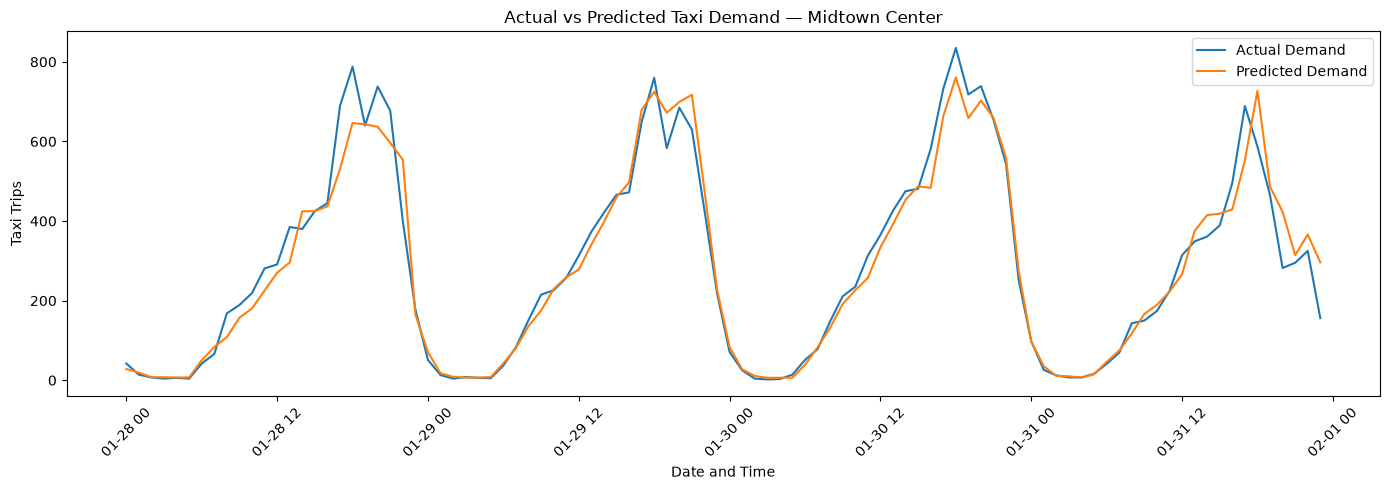

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

plt.plot(
    midtown_results["datetime"],
    midtown_results["demand"],
    label="Actual Demand"
)

plt.plot(
    midtown_results["datetime"],
    midtown_results["predicted_demand"],
    label="Predicted Demand"
)

plt.xlabel("Date and Time")
plt.ylabel("Taxi Trips")
plt.title("Actual vs Predicted Taxi Demand — Midtown Center")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

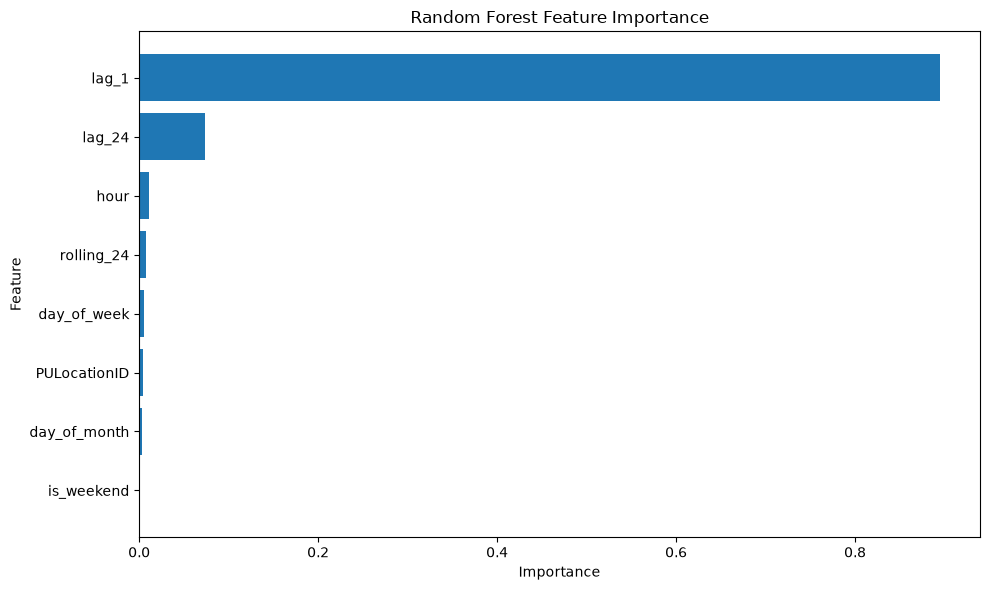

In [65]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [67]:
powerbi_path = r"C:\Users\Sai Pratheek\OneDrive\Desktop\Taxi Demand Prediction\04_Power BI"

import os
os.makedirs(powerbi_path, exist_ok=True)

In [69]:
hourly_zone_demand.to_parquet(
    os.path.join(powerbi_path, "hourly_zone_demand.parquet"),
    index=False
)

print("1/4 Hourly demand dataset saved successfully!")
print("Rows:", len(hourly_zone_demand))
print("Columns:", len(hourly_zone_demand.columns))

1/4 Hourly demand dataset saved successfully!
Rows: 194184
Columns: 13


In [71]:
ml_predictions = test_df[
    [
        "datetime",
        "PULocationID",
        "pickup_borough",
        "pickup_zone",
        "demand"
    ]
].copy()

ml_predictions["predicted_demand"] = y_test_pred

ml_predictions.to_csv(
    os.path.join(powerbi_path, "ml_predictions.csv"),
    index=False
)

print("2/4 ML predictions saved successfully!")
print("Rows:", len(ml_predictions))

2/4 ML predictions saved successfully!
Rows: 25056


In [73]:
feature_importance.to_csv(
    os.path.join(powerbi_path, "feature_importance.csv"),
    index=False
)

print("3/4 Feature importance saved successfully!")

3/4 Feature importance saved successfully!


In [75]:
model_performance = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [test_mae, test_rmse, test_r2]
})

model_performance.to_csv(
    os.path.join(powerbi_path, "model_performance.csv"),
    index=False
)

print("4/4 Model performance saved successfully!")
print(model_performance)

4/4 Model performance saved successfully!
  Metric      Value
0    MAE   3.629241
1   RMSE  11.860598
2     R2   0.962747


In [77]:
print("\nFiles in 04_Power BI folder:")

for file in os.listdir(powerbi_path):
    print("-", file)


Files in 04_Power BI folder:
- feature_importance.csv
- hourly_zone_demand.parquet
- ml_predictions.csv
- model_performance.csv
